<a href="https://colab.research.google.com/github/catalinaMaria1/TemaIA/blob/Tema2%C3%8EA/Ridge_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RIDGE REGRESSION
Cel mai bun alpha: 0.01
RMSE: 0.7753993341516121


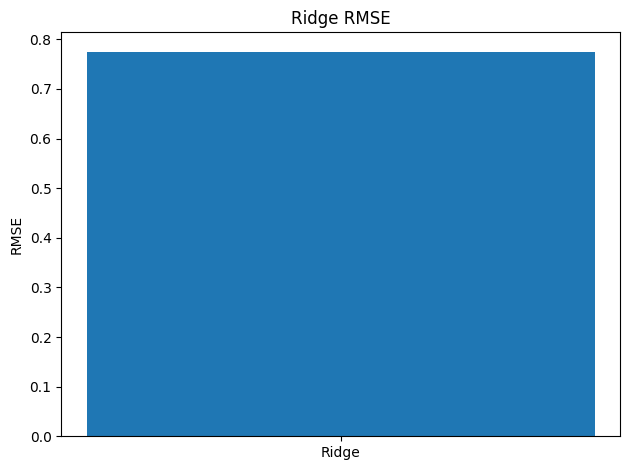

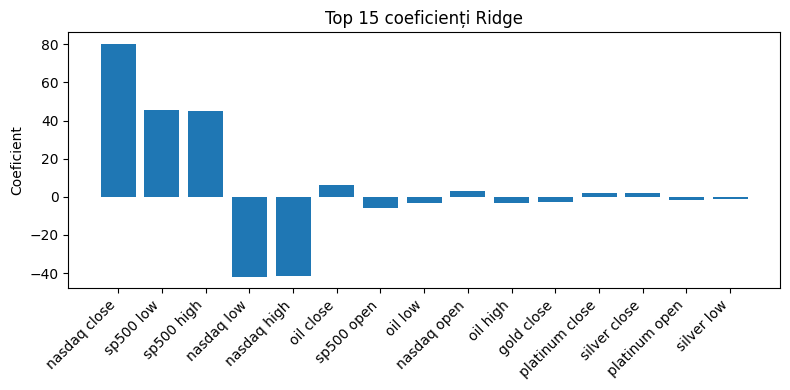

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

df = pd.read_csv("/content/financial_regression.csv")
df = df.dropna(subset=["sp500 close"])

target_col = "sp500 close"
y = df[target_col]
X = df.drop(columns=[target_col, "date"])
X = X.select_dtypes(include=["int64", "float64"])

# Împărțire
n = len(df)
n_train = int(0.8 * n)
X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]

tscv = TimeSeriesSplit(n_splits=5)

# Ridge model si GridSearch
ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_grid = GridSearchCV(
    ridge_pipeline,
    {"model__alpha": [0.01, 0.1, 1, 10, 50, 100]},
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)
ridge_best = ridge_grid.best_estimator_
ridge_pred = ridge_best.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("RIDGE REGRESSION")
print("Cel mai bun alpha:", ridge_grid.best_params_["model__alpha"])
print("RMSE:", ridge_rmse)

#Ridge coef
ridge_coefs = ridge_best.named_steps["model"].coef_
ridge_coef_df = pd.DataFrame({"feature": X.columns, "coef": ridge_coefs})
ridge_coef_df["abs_coef"] = ridge_coef_df["coef"].abs()
ridge_top15 = ridge_coef_df.sort_values("abs_coef", ascending=False).head(15)

# RMSE
plt.figure()
plt.bar(["Ridge"], [ridge_rmse])
plt.ylabel("RMSE")
plt.title("Ridge RMSE")
plt.tight_layout()
plt.show()

# 15 coef
plt.figure(figsize=(8,4))
plt.bar(ridge_top15["feature"], ridge_top15["coef"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Coeficient")
plt.title("Top 15 coeficienti Ridge")
plt.tight_layout()
plt.show()
